# Day 21 Pre-Class Assignment

------

### <p style="text-align: right;"> &#9989;&nbsp; Put your name here</p>

## Multiple Testing and p-Hacking; or the dangers of torturing data on YOUR favor

<img src="https://imgs.xkcd.com/comics/significant.png" style="display:block; margin-left: auto; margin-right: auto; width: 50%" alt="This comic is about data dredging (aka p-hacking), and the misrepresentation of science and statistics in the media.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://xkcd.com/882/" target="_blank">xkcd.com</a></p>

### Learning goals for today's pre-class assignment

* Recognize the dangers of muliple testing and state ways that we can obtain **not** significant results and yet have a small p-value
* Use `stats` to perform Benjamini-Hochberg procedures to adjust p-values whenever doing multiple testing
* Be aware of Mann-Whitney's U-test as an alternative to Student's t-test

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

----

## 1. p-hacking or the ethics of responsible research

[Data dredging](https://en.wikipedia.org/wiki/Data_dredging)&mdash;also known as p-hacking, cherry picking, data snooping&mdash;is the misuse of data analysis to find patterns in data that can be presented as statistically significant, thus dramatically increasing the risk of false positives. This can be done in several ways, the two most common being some sort of:

- Perform many statistical tests on the data and only report those that come back with significant results.
- Add/remove one datapoint at a time until the p-value is deemed small.

### 1.1 But how exactly can you p-hack, maybe without realizing it?

&#9989;&nbsp; **Task** 

Watch this video that goes into more details on how p-hacking can occur inadvertedly for each of the two points raised above:

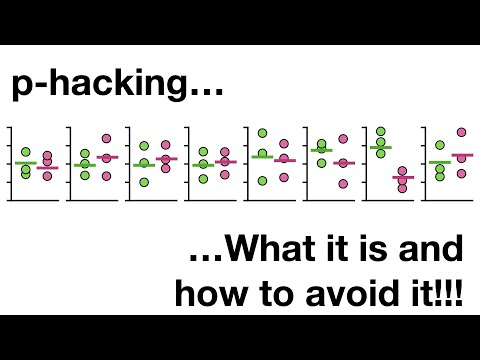

In [1]:
from IPython.display import YouTubeVideo, HTML
YouTubeVideo('HDCOUXE3HMM', width=640, height=360)

&#9989;&nbsp; **Question 1** 

Like Josh said in the video above, say you are testing whether one of the 100 different drugs you've developed actually works. That means that you perform a t-test between a placebo and each of these 100 drugs&mdash;so 100 t-tests in total.

- If one drug returns a p-value of 0.01, why can't you just call it a day and say you've found a drug that works?
- As usual, you say that a p-value smaller than 0.05 will be considered significant. If in reality none of your 100 drugs work, how many of them would still return a significant p-value?

<font size=+3>&#9998;</font> *Explain your answers here.*


&#9989;&nbsp; **Question 2** 

We still hold on to the rule that "0.05 or lower is significant." Which means: there is a 1 in 20 chance that whatever difference/trend/effect we measure in our data, it is due to sheer chance.

Now let's suppose you only have developed a single drug. To check whether this drug has an effect compared to placebo, you run 20 separate statistical tests with the same data:

- Kolmogorov-Smirnov &nbsp;&rarr;&nbsp; p-value = 0.3
- Mann-Whitney &nbsp;&rarr;&nbsp; p-value = 0.2
- Welch's &nbsp;&rarr;&nbsp; p-value = 0.5
- [...16 other tests...]
- t-test &nbsp;&rarr;&nbsp; p-value = 0.01

All these tests check whether two samples are the same or not&mdash;we will discuss more about them near the end of the course, for the time being, think of them as t-test variations. Your data fulfills the requirements for all of them. 

- The t-test returned a small p-value. Can you just call it a day and say you've found a drug that works?

<font size=+3>&#9998;</font> *Explain your answer here.*


&#9989;&nbsp; **Question 3** 

Same as in Q2, you have a single drug to test. Your statistical setup looks like;

1. You collect data from 10 placebo subjects and 10 drug-treated subjects.
1. You **randomly** select with replacement **only** 5 and 5 (5 placebo, 5 drug-treated)
1. Then you perform a t-test with these (the only test you perform)
1. You repeat steps 2&ndash;3 multiple times: You **randomly** select another 5 and 5 and peform a t-test.

Eventually, you get a p-value of 0.01.

- Can you just call it a day and say you've found a drug that works?
- What if we were replacing *without* replacement?

<font size=+3>&#9998;</font> *Explain your answer here.*


&#9989;&nbsp; **Question 4** 

Similar to Q3, but you change your statistical setup to resemble bootstrap:

1. You collect data from 10 placebo subjects and 10 drug-treated subjects.
1. Like in bootstrap, you **randomly** select with replacement 10 and 10&mdash;instead of 5 and 5.
1. Then you perform a t-test with these (the only test you perform)
1. You repeat steps 2&ndash;3 multiple times: You **randomly** select another 10 and 10 and peform a t-test.

Eventually, we get a p-value of 0.02

- Can you just call it a day and say you've found a drug that works?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Question 5** 

Go back to the top of the Notebook and read again the xkcd comic.

- Do you think the main characters p-hacked?

<font size=+3>&#9998;</font> *Justify your answer here.*


&#9989;&nbsp; **Question 6: Full context &amp; multiple testing** 

At its core, the problem of multiple testing is that if you look for something enough times, *eventually* you'll eventually find it due to sheer chance. In a wider context, some events are not as impressive&mdash;or significant&mdash;as they might appear at first.

Imagine that you go to Disneyland (or your favorite amusement park) with your family/friends. Think of the odds of the following:
- By sheer chance, you stumble upon a relative of yours.
- There is at least one Disneyland patron that stumbles upon a relative of theirs by sheer chance.

Which statement has a higher probability of happening (and thus it is less impressive)? Can you write an equivalent pair of statements but with jelly bean colors and acne instead of Disneyland and relatives?

<font size=+3>&#9998;</font> *Write your answers here.*


---

## 2. Adjust p-values for false positives and multiple testing

Plenty of times, you'll find yourself computing 100s if not 10,000s t-tests at a time. Common scenarios:

- You're checking for significant differences in yield in a panel of 100 lines of maize.
    - That means you check each of the 1000 lines against the other 99, resulting in $100\times99/2 \approx 5$k different pairs and 5k t-tests.
- You're dealing with control and treatment subjects. You are checking which of their 20,000 genes are differentially expressed
    - In other words, you're looking for genes which are much more expressed in control compared to treatment, or viceversa.
    - That means you perform 20,000 t-tests

These situations are prime ground for p-hacking and for **false positives**: results that are reported as significant but in reality they are not so.

The good news is that we can adjust the resulting p-values so that we keep only the truly significant results. Here we will only discuss two of the most common approaches you might find out there.

### 2.1 The Bonferroni correction

The simplest correction is to multiply every p-value by the total number of tests. If you did $m$ tests&mdash;and you have $m$ p-values $p_1,p_2,\ldots p_m$, then your Bonferroni-corrected p-values are $mp_1,mp_2,\ldots,mp_m$. Corrected p-values are capped at $1$.

For example, say that the correlation between acne and green jelly beans has an associated p-value of $0.02$. You might call the press and report a significant result. But you actually checked for 20 colors. So your Bonferroni-corrected p-value actually is $20\times0.02 = 0.4$. Not so impressive now, is it?

Turns out that the green jelly beans were a false positive.

&#9989;&nbsp; **Question 7**

Like in Q1, you are checking whether any of your 100 new drugs works better than placebo. 

- Drug A produces a p-value of 0.003
- Drug B produces a p-value of 0.0001
- The other 98 drugs produce p-values larger than 0.05

Assuming that any p-value smaller than 0.05 will be deemed significant, are drugs A and B true or false positives?

In [2]:
# feel free to use Python as a calculator
apval = 0.003
bpval = 0.0001


<font size=+3>&#9998;</font> *Justify your answer here.*


### 2.2 To Bonferroni or to not Bonferroni, that is the question (and related corrections)

The Bonferroni correction has good and bad news:

- The good news is that it is really good at keeping at bay false positives.

- The bad news is that it is extremely *conservative*: it is very prone to generate **false negatives**. You might find Bonferroni corrected p-values that are reported as *not* significant when in reality they should be considered significant.

In general, only consider Bonferroni when you have thousands (if not millions) of p-values and you only want to focus on a handful of results. For example, you are looking at 20k genes and you only want to make knock-out lines for 3&ndash;4 genes.

Out in the wild you might find Bonferroni-like corrections, like [Holm](https://en.wikipedia.org/wiki/Holm%E2%80%93Bonferroni_method) or [&Scaron;id&aacute;k](https://en.wikipedia.org/wiki/%C5%A0id%C3%A1k_correction). These keep at bay false positives the same way as Bonferroni while being *slightly* less conservative. Keyword is *slightly*.

### 2.3 The Benjamini-Hochberg (BH) procedure *aka* False Discovery Rate (FDR)

A very different way to correct p-values is through the Benjamini-Hochberg procedure&mdash;sometimes announced as False Discovery Rate. This method is much less conservative than Bonferroni and should be your go to whenever you are not looking at 1000s of tests.

&#9989;&nbsp; **Task** 

Watch this other StatQuest on how to control false positives with the Benjamini-Hochberg procedure

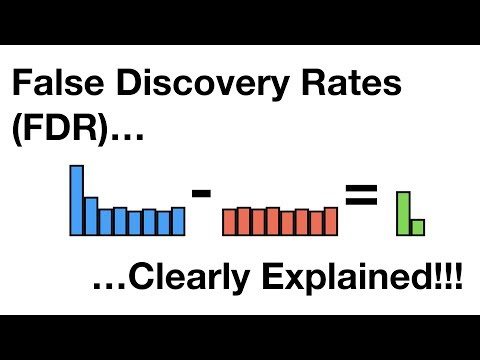

In [3]:
from IPython.display import YouTubeVideo, HTML
YouTubeVideo('K8LQSvtjcEo', width=640, height=360)

&#9989;&nbsp; **Question 8**

Say you are a research assistant at [MU's UDAIR](https://udair.missouri.edu/mu-data/student-enrollment/) (University Data, Analytics, and Institutional Research) with access to aggregated data of student enrollment since 1839 (when MU was founded). 

- Describe a research question that would produce numerous t-tests that would then require BH adjustment
- (Assume that your data is normal)

<font size=+3>&#9998;</font> *Describe your experiment here.*


---

## 3. Practicing with switchgrass

Let's revisit the switchgrass dataset from [Ricketts et al (2023)](https://doi.org/10.1111/gcbb.13046). Let's focus on Figure 2a, where: 
- For every location and genotype, they have 5 replicates for yield data per year, and 4 years of data: sample size is thus $5\times4=20$.
- Then they check whether there are significant yield differences between different genotypes (for separate locations).

<img src="https://onlinelibrary.wiley.com/cms/asset/0eb15fd0-72ec-411f-b40b-e86c2125616b/gcbb13046-fig-0002-m.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 60%" alt="End-of-season total switchgrass biomass yield for each cultivar averaged over the 4âyears of the study. Colors indicate the different cultivars and letters indicate significant differences between cultivar biomass yields within each site found using Wilcox posthoc tests (pâ<â0.05; n = 5 replicatesâÃâ4âyears = 20). Boxplot lines represent the median, first and third quartiles, and whiskers represent the minimum and maximum values, except for outliers which are represented by circles.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1111/gcbb.13046" target="_blank">Ricketts (2023)</a></p>

### 3.1 Load and wrangle the data

We start by importing the needed packages, then load the `HARVEST.tsv` dataset

In [4]:
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
nudge = rng.uniform(-0.15,.15, 1000)

colors = ['r', 'orange', 'forestgreen', 'palegreen', 'royalblue', 'blueviolet']
markers = ['o','^','v','s','D','>']

data = pd.read_csv('HARVEST.tsv', sep='\t')
print('There are',len(data),'rows')
data.head()

There are 360 rows


,YEAR,SITE,SITE_YR,PLOT_GL,Block,PLOT,GENO,ECOTYPE,TIME_SET,ADJ_FULL_JD,...,DLY240_TMIN_Avg,DLY240_Pen_PET,DLY270_PRCP_Totals,DLY270_TMAX_Avg,DLY270_TMIN_Avg,DLY270_Pen_PET,DLY365_PRCP_Totals,DLY365_TMAX_Avg,DLY365_TMIN_Avg,DLY365_Pen_PET
0,Y2017,IL,IL_17,IL.1A,IL.1,1A,Liberty,Hybrids,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
1,Y2017,IL,IL_17,IL.1B,IL.1,1B,Carthage,Hybrids,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
2,Y2017,IL,IL_17,IL.1C,IL.1,1C,Kanlow,Lowlands,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
3,Y2017,IL,IL_17,IL.1D,IL.1,1D,Blackwell,Uplands,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN
4,Y2017,IL,IL_17,IL.1E,IL.1,1E,Alamo,Lowlands,Harvest,IL117329,...,9.556829,119.284155,1025.652,19.863785,8.355337,114.936714,NaN,NaN,NaN,NaN


- Visualize the data as jitterplots: one jitter per site and genotype.
- The central point is the mean, while the error bars are the 95% confidence interval of the mean.

**Important**: [`yield` is an in-built Python statement for functions](https://docs.python.org/3/reference/simple_stmts.html#yield). Never ever name a variable `yield`.


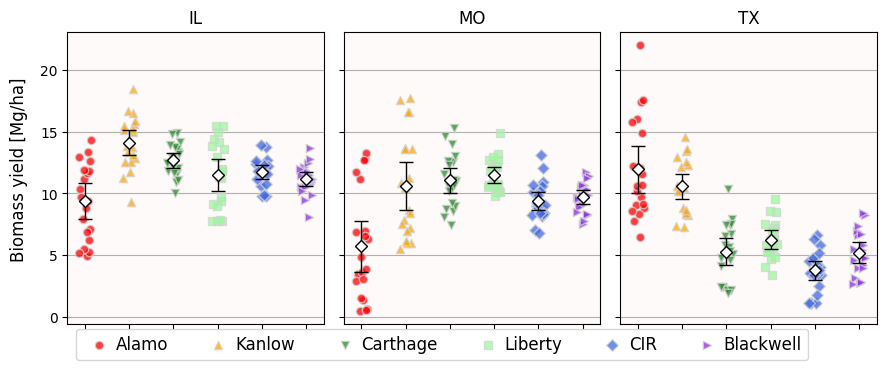

In [5]:
sites = data['SITE'].unique()
genos = ['Alamo', 'Kanlow', 'Carthage', 'Liberty', 'CIR', 'Blackwell']

fs = 12
fig, ax = plt.subplots(1,len(sites),figsize=(len(sites)*3,3.5), sharex=True, sharey=True)
for i in range(len(sites)):
    ax[i].set_title(sites[i], fontsize=fs)
    ax[i].set_facecolor('snow')
    ax[i].grid(axis = 'y', zorder=1)
    ax[i].set_xticks(range(len(genos)), '')
    
    for j in range(len(genos)):
        
        # Look only at the yield data from one site and one genotype
        yields = data.loc[ (data['SITE'] == sites[i]) & (data['GENO'] == genos[j]), 'BIOMASS_AVG_Mg_ha' ]
        ci = stats.t.ppf(0.975, len(yields) - 1)*yields.sem()
        
        ax[i].scatter(j + nudge[:len(yields)], yields, 
                      c=colors[j], marker=markers[j], alpha=0.75, ec='lightgray', label=genos[j], zorder=2)
        ax[i].errorbar(j, yields.mean(), yerr=ci, color='k', mew=1, elinewidth=1, capsize=5, mfc='w', marker='D', zorder=3)

handles,labels = ax[0].get_legend_handles_labels()
fig.legend(handles[:len(genos)], labels[:len(genos)], ncols=len(genos),
           loc = 'center', bbox_to_anchor=(0.5,0), handletextpad=0, fontsize=fs)
fig.supylabel('Biomass yield [Mg/ha]', fontsize=fs)
fig.tight_layout();

&#9989;&nbsp; **Task 9 [Don't get too hung up on this Task; we'll discuss in class later]** 

- Look at the [`.get_legend_handles_labels` function](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.get_legend_handles_labels.html) we used above.
- Look at the `fig.legend` parameters that we used in the plot above.
- Read what these parameters do in the [`legend` documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html). If unsure, try changing them and see what happens.
- Are there any parts of the plot code above that are confusing?

<font size=+3>&#9998;</font> *Put your three answers here.*


&#9989;&nbsp; **Question 10**

Let's focus just on the Missouri data.

- Based on the visualization alone, do you think there is a cultivar that is statiscally different from the rest?
- What two cultivars might be statistically similar?

<font size=+3>&#9998;</font> *Put your three answers here.*


### 3.2 Missouri and the statistical differences

[Ricketts et al. (2023)](https://doi.org/10.1111/gcbb.13046) say early in section 2.5 (Data processing and statistical analysis):

> Because our data were not normally distributed, we used non-parametric tests (Wilcox posthoc tests [sic] with Benjamini and Hochberg p-value corrections) to compare biomass yields among cultivars and ecotypes at each site regardless of year, among sites within each cultivar, and year-to-year changes in yield.

Sidenote: The authors meant the [(Wilcoxon)-Mann-Whitney U-tests](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test) that we discussed in Day 19: the non-parametric alternative to Welch's. This "typo" is probably because R calls performs the U-test with [the `stats::wilcox.test` function](https://cran.r-project.org/doc/manuals/r-release/packages/stats/refman/stats.html#wilcox.test).

Back to Python:

- We write a nested loop to consider all pairs
- Notice the start and end points: this is to avoid comparing a cultivar to itself
- We also keep track of all the pvalues in a Series.

In case you're wondering why a Series:
- A Series is much better than a list or an array because we can keep additional information: what cultivar vs what cultivar are we comparing
- A dictionary can also keep additional information, but we cannot do quick stats and math with it.

In [6]:
# Do a Mann-Whitney U-test between every pair of cultivars in Missouri

site = 'MO'

# Get a subDataFrame with just the Missouri data
df = data[data['SITE'] == site]
pvals = pd.Series()

for i in range(len(genos) - 1):
    # Just the yield data for one cultivar
    yi = df.loc[df['GENO'] == genos[i], 'BIOMASS_AVG_Mg_ha']
    
    for j in range(i+1, len(genos)):
        
        # Yield data for another cultivar
        yj = df.loc[df['GENO'] == genos[j], 'BIOMASS_AVG_Mg_ha']

        # Mann-Whitney U-test
        utest = stats.mannwhitneyu(yi, yj)

        pvals.loc[genos[i]+' vs '+genos[j]] = utest.pvalue
pvals

Alamo vs Kanlow          0.001227
Alamo vs Carthage        0.000687
Alamo vs Liberty         0.000687
Alamo vs CIR             0.005115
Alamo vs Blackwell       0.005115
Kanlow vs Carthage       0.394171
Kanlow vs Liberty        0.297677
Kanlow vs CIR            0.818149
Kanlow vs Blackwell      0.989209
Carthage vs Liberty      0.473481
Carthage vs CIR          0.014364
Carthage vs Blackwell    0.049864
Liberty vs CIR           0.000161
Liberty vs Blackwell     0.000305
CIR vs Blackwell         0.394171
dtype: float64

### 3.3 Adjusting p-values

Looking at the `pvals` Series and at the jitterplot above, we get small p-values whenever the jitters are visually different. And we get large p-values otherwise. 

But remember: a p-value of 0.05 indicates that there is a 1 in 20 probability that whatever difference we see in the data, it was produced by sheer chance and not any underlying biology. In this case, we are making 15 comparisons in total (check `len(pvals)`). So maybe, just maybe, one of the "significant" p-values is a false positive.

&#9989;&nbsp; **Question 11** 

Carthage vs Blackwell report a p-value of 0.0499, which is significant.

- Looking at the jitterplot and their 95% CIs, do you think this is a true positive or a false positive?

<font size=+3>&#9998;</font> *Put your answer*


The good news is that SciPy `stats` can do p-value adjustment easily with [its `.false_discovery_control` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.false_discovery_control.html). Notice that it has two `method`s and that by defaut it uses `bh`, Benjamini-Hochberg. This is the method described in the FDR StatQuest above and also the one used by Ricketts et al (2023).

In [7]:
# Applying a Benjamini-Hochberg correction to our pvalues
# By default, it will return a NumPy array
# But we will then put the output in a Series to keep track of what comparison is which

bh_pvals = pd.Series( stats.false_discovery_control(pvals), index=pvals.index)
bh_pvals

Alamo vs Kanlow          0.003682
Alamo vs Carthage        0.002576
Alamo vs Liberty         0.002576
Alamo vs CIR             0.010961
Alamo vs Blackwell       0.010961
Kanlow vs Carthage       0.492714
Kanlow vs Liberty        0.446515
Kanlow vs CIR            0.876589
Kanlow vs Blackwell      0.989209
Carthage vs Liberty      0.546324
Carthage vs CIR          0.026932
Carthage vs Blackwell    0.083106
Liberty vs CIR           0.002286
Liberty vs Blackwell     0.002286
CIR vs Blackwell         0.492714
dtype: float64

Now Carthage vs Blackwell has an adjusted p-value of 0.08, which confirms our visual intuition that they did not look *that* different.
We can also check that they are the only pair that went from below 0.05 to above 0.05 after the Benjamini-Hochberg adjustment.

In [8]:
# Check which p-vals went from < 0.05 to >= 0.05

signif = 0.05
pvals[(bh_pvals >= signif) & (pvals < signif)]

Carthage vs Blackwell    0.049864
dtype: float64

## 4. Relevant sidenotes 

### 4.1 On published inaccuracies

If you look at Figure 2a from [Ricketts et al (2023)](https://doi.org/10.1111/gcbb.13046), it says that the switchgrass yield between Carthage and Blackwell cultivars is significantly different in Missouri.

But we just saw they are not! We even repeated the steps Ricketts themselves described!

&#9989;&nbsp; **Question 12**

- What do you think went wrong? Give it your best guess.

<font size=+3>&#9998;</font> *Put your answer*


### 4.2 On the underlying issues behind p-hacking

In a way, you can argue that much of the p-hacking you see in academic literature is due to the pervasive [Publish or Perish](https://en.wikipedia.org/wiki/Publish_or_perish) mindset: if you don't publish, your academic standing is at risk. However:

- Papers must be published in reputable journals
- Reputable journals will publish you if and only if you have significant results
- A result is deemed significant if and only if it has an associated p-value lower than 0.05

&#9989;&nbsp; **Question 13** 

Picture this: you are an emerging scientist, with a really cool idea that biologically speaking makes sense. You follow through with an experiment that ultimately produces a **adjusted** p-value of 0.08. No correlation with Carthage.

- What would you do next?

<font size=+3>&#9998;</font> *Put your answer*


---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri